# Stock Momentum Strategy

Test simple stock-only strategies using SPY and QQQ.

## Code Steps

1. Load raw close prices for SPY and QQQ.
2. Calculate daily returns.
3. Build trading signals from today's close only.
4. Apply those signals to tomorrow's returns to avoid lookahead bias.
5. Subtract a small transaction cost when the position changes.
6. Compare strategies using Sharpe, annual return, volatility, max drawdown, Calmar ratio, exposure, and turnover.
7. Save the daily strategy returns and summary table.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "yfinance_SPY_QQQ_TLT_GLD_2015-01-01_1d.csv"
DAILY_OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "stock_strategy_daily.csv"
RESULTS_OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "stock_strategy_results.csv"

STOCK_ASSETS = ["SPY", "QQQ"]
TRADING_DAYS = 252
TRANSACTION_COST_BPS = 1
TRANSACTION_COST = TRANSACTION_COST_BPS / 10_000

In [2]:
# Step 1: load close prices from the raw yfinance output.
raw = pd.read_csv(RAW_PATH, header=[0, 1], index_col=0, parse_dates=True)
raw = raw[raw.index.notna()]
raw.index.name = "Date"

close = raw.xs("Close", axis=1, level=1)[STOCK_ASSETS]
close = close.sort_index().dropna()

close.head()

Ticker,SPY,QQQ
Date,,
2015-01-02,169.687820,94.561165
2015-01-05,166.623352,93.174034
2015-01-06,165.053955,91.924744
2015-01-07,167.110687,93.109749
2015-01-08,170.076004,94.891861


In [3]:
# Step 2: calculate daily returns.
# returns.loc[t] is the return from t-1 close to t close.
returns = close.pct_change()

# forward_returns.loc[t] is the return from t close to the next trading day's close.
# This is what today's signal would earn tomorrow.
forward_returns = returns.shift(-1)

returns.tail()

Ticker,SPY,QQQ
Date,,
2026-06-22,-0.003147,-0.002510
2026-06-23,-0.014522,-0.032929
2026-06-24,-0.000464,-0.004246
2026-06-25,0.001446,0.008106
2026-06-26,-0.007231,-0.013764


In [4]:
def empty_weights() -> pd.DataFrame:
    return pd.DataFrame(0.0, index=close.index, columns=STOCK_ASSETS)


def buy_and_hold_weights(asset: str) -> pd.DataFrame:
    weights = empty_weights()
    weights[asset] = 1.0
    return weights


def long_cash_momentum_weights(asset: str, window: int) -> pd.DataFrame:
    weights = empty_weights()
    momentum = close[asset].pct_change(window)
    weights.loc[momentum > 0, asset] = 1.0
    return weights


def stock_rotation_weights(window: int) -> pd.DataFrame:
    weights = empty_weights()
    momentum = close[STOCK_ASSETS].pct_change(window)
    best_asset = momentum.fillna(-np.inf).idxmax(axis=1)
    best_momentum = momentum.max(axis=1)

    # If both stock ETFs have negative momentum, stay in cash.
    active_dates = best_momentum[best_momentum > 0].index
    for date in active_dates:
        weights.at[date, best_asset.at[date]] = 1.0

    return weights


def equal_positive_momentum_weights(window: int) -> pd.DataFrame:
    weights = empty_weights()
    momentum = close[STOCK_ASSETS].pct_change(window)
    positive = momentum > 0
    positive_count = positive.sum(axis=1)

    for asset in STOCK_ASSETS:
        weights.loc[positive[asset], asset] = 1 / positive_count[positive[asset]]

    return weights

In [5]:
def max_drawdown(strategy_returns: pd.Series) -> float:
    equity_curve = (1 + strategy_returns).cumprod()
    running_high = equity_curve.cummax()
    drawdown = equity_curve / running_high - 1
    return drawdown.min()


def backtest_strategy(name: str, weights: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, float | str]]:
    weights = weights.reindex(close.index).fillna(0.0)

    gross_returns = (weights * forward_returns[STOCK_ASSETS]).sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))
    costs = turnover * TRANSACTION_COST
    net_returns = gross_returns - costs

    daily = pd.DataFrame(
        {
            "Date": close.index,
            "strategy": name,
            "gross_return": gross_returns,
            "transaction_cost": costs,
            "strategy_return": net_returns,
            "turnover": turnover,
            "exposure": weights.sum(axis=1),
        }
    ).dropna(subset=["strategy_return"])

    daily["equity_curve"] = (1 + daily["strategy_return"]).cumprod()

    strategy_returns = daily["strategy_return"]
    years = len(daily) / TRADING_DAYS
    total_return = daily["equity_curve"].iloc[-1] - 1
    annual_return = (1 + total_return) ** (1 / years) - 1
    annual_volatility = strategy_returns.std(ddof=0) * np.sqrt(TRADING_DAYS)
    sharpe = np.nan if annual_volatility == 0 else strategy_returns.mean() / strategy_returns.std(ddof=0) * np.sqrt(TRADING_DAYS)
    drawdown = max_drawdown(strategy_returns)
    calmar = np.nan if drawdown == 0 else annual_return / abs(drawdown)

    metrics = {
        "strategy": name,
        "rows": len(daily),
        "total_return": total_return,
        "annual_return": annual_return,
        "annual_volatility": annual_volatility,
        "sharpe": sharpe,
        "max_drawdown": drawdown,
        "calmar": calmar,
        "avg_exposure": daily["exposure"].mean(),
        "annual_turnover": daily["turnover"].mean() * TRADING_DAYS,
        "total_transaction_cost": daily["transaction_cost"].sum(),
        "positive_day_rate": (strategy_returns > 0).mean(),
    }

    return daily, metrics

In [6]:
# Steps 3 and 4: define stock-only strategies.
strategy_weights = {
    "buy_hold_SPY": buy_and_hold_weights("SPY"),
    "buy_hold_QQQ": buy_and_hold_weights("QQQ"),
}

for window in [10, 20, 60]:
    strategy_weights[f"SPY_momentum_{window}d_long_cash"] = long_cash_momentum_weights("SPY", window)
    strategy_weights[f"QQQ_momentum_{window}d_long_cash"] = long_cash_momentum_weights("QQQ", window)
    strategy_weights[f"SPY_QQQ_rotation_{window}d"] = stock_rotation_weights(window)
    strategy_weights[f"SPY_QQQ_equal_positive_{window}d"] = equal_positive_momentum_weights(window)

len(strategy_weights)

14

In [7]:
# Steps 5 and 6: run the backtests and rank by Sharpe ratio.
daily_frames = []
metric_rows = []

for name, weights in strategy_weights.items():
    daily, metrics = backtest_strategy(name, weights)
    daily_frames.append(daily)
    metric_rows.append(metrics)

strategy_daily = pd.concat(daily_frames, ignore_index=True)
strategy_results = pd.DataFrame(metric_rows).sort_values("sharpe", ascending=False)

strategy_results

,strategy,rows,total_return,annual_return,annual_volatility,sharpe,max_drawdown,calmar,avg_exposure,annual_turnover,total_transaction_cost,positive_day_rate
7,QQQ_momentum_20d_long_cash,2887,3.863251,0.148049,0.136078,1.082961,-0.199522,0.742019,0.671631,20.076204,0.0230,0.380672
9,SPY_QQQ_equal_positive_20d,2887,3.149579,0.132255,0.121611,1.082521,-0.177977,0.743103,0.724281,33.518531,0.0384,0.405958
8,SPY_QQQ_rotation_20d,2887,3.300511,0.135791,0.131148,1.036855,-0.179346,0.757146,0.724281,50.976100,0.0584,0.403879
5,SPY_QQQ_equal_positive_10d,2887,2.643281,0.119467,0.123324,0.977053,-0.178972,0.667519,0.699688,48.182889,0.0552,0.390371
6,SPY_momentum_20d_long_cash,2887,1.929557,0.098364,0.103784,0.956186,-0.135095,0.728105,0.681676,20.599931,0.0236,0.375823
4,SPY_QQQ_rotation_10d,2887,2.647726,0.119587,0.132450,0.919348,-0.189766,0.630181,0.699688,70.004849,0.0802,0.392103
1,buy_hold_QQQ,2887,6.471566,0.191896,0.219315,0.910578,-0.351187,0.546420,1.000000,0.000000,0.0000,0.561136
2,SPY_momentum_10d_long_cash,2887,1.695482,0.090409,0.103786,0.886020,-0.154985,0.583338,0.647385,31.074472,0.0356,0.352269
10,SPY_momentum_60d_long_cash,2887,1.840784,0.095417,0.110047,0.883567,-0.204128,0.467440,0.742293,9.514375,0.0109,0.410807
13,SPY_QQQ_equal_positive_60d,2887,2.261402,0.108700,0.134551,0.834651,-0.215853,0.503582,0.777277,17.108417,0.0196,0.433322


In [8]:
# Readable percent view.
display_results = strategy_results.copy()
percent_cols = [
    "total_return",
    "annual_return",
    "annual_volatility",
    "max_drawdown",
    "calmar",
    "avg_exposure",
    "annual_turnover",
    "total_transaction_cost",
    "positive_day_rate",
]

for col in percent_cols:
    display_results[col] = display_results[col].map(lambda value: f"{value:.2%}")

display_results[[
    "strategy",
    "sharpe",
    "total_return",
    "annual_return",
    "annual_volatility",
    "max_drawdown",
    "calmar",
    "avg_exposure",
    "annual_turnover",
    "total_transaction_cost",
    "positive_day_rate",
]]

,strategy,sharpe,total_return,annual_return,annual_volatility,max_drawdown,calmar,avg_exposure,annual_turnover,total_transaction_cost,positive_day_rate
7,QQQ_momentum_20d_long_cash,1.082961,386.33%,14.80%,13.61%,-19.95%,74.20%,67.16%,2007.62%,2.30%,38.07%
9,SPY_QQQ_equal_positive_20d,1.082521,314.96%,13.23%,12.16%,-17.80%,74.31%,72.43%,3351.85%,3.84%,40.60%
8,SPY_QQQ_rotation_20d,1.036855,330.05%,13.58%,13.11%,-17.93%,75.71%,72.43%,5097.61%,5.84%,40.39%
5,SPY_QQQ_equal_positive_10d,0.977053,264.33%,11.95%,12.33%,-17.90%,66.75%,69.97%,4818.29%,5.52%,39.04%
6,SPY_momentum_20d_long_cash,0.956186,192.96%,9.84%,10.38%,-13.51%,72.81%,68.17%,2059.99%,2.36%,37.58%
4,SPY_QQQ_rotation_10d,0.919348,264.77%,11.96%,13.24%,-18.98%,63.02%,69.97%,7000.48%,8.02%,39.21%
1,buy_hold_QQQ,0.910578,647.16%,19.19%,21.93%,-35.12%,54.64%,100.00%,0.00%,0.00%,56.11%
2,SPY_momentum_10d_long_cash,0.886020,169.55%,9.04%,10.38%,-15.50%,58.33%,64.74%,3107.45%,3.56%,35.23%
10,SPY_momentum_60d_long_cash,0.883567,184.08%,9.54%,11.00%,-20.41%,46.74%,74.23%,951.44%,1.09%,41.08%
13,SPY_QQQ_equal_positive_60d,0.834651,226.14%,10.87%,13.46%,-21.59%,50.36%,77.73%,1710.84%,1.96%,43.33%


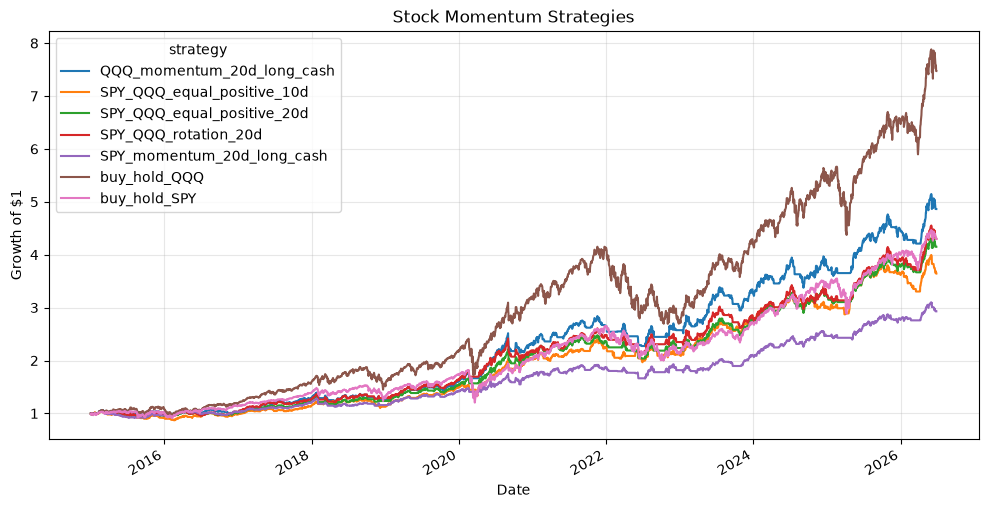

In [9]:
# Plot the top strategies against buy-and-hold SPY and QQQ.
top_strategies = strategy_results.head(5)["strategy"].tolist()
plot_strategies = list(dict.fromkeys(["buy_hold_SPY", "buy_hold_QQQ"] + top_strategies))

plot_frame = strategy_daily[strategy_daily["strategy"].isin(plot_strategies)]
plot_frame = plot_frame.pivot(index="Date", columns="strategy", values="equity_curve")

ax = plot_frame.plot(figsize=(12, 6))
ax.set_title("Stock Momentum Strategies")
ax.set_ylabel("Growth of $1")
ax.grid(True, alpha=0.3)
plt.show()

In [10]:
# Step 7: save outputs for later comparison with ML models.
strategy_daily.to_csv(DAILY_OUTPUT_PATH, index=False)
strategy_results.to_csv(RESULTS_OUTPUT_PATH, index=False)

DAILY_OUTPUT_PATH, RESULTS_OUTPUT_PATH

(WindowsPath('C:/Users/nqmin/Documents/Project/Predictions/data/processed/stock_strategy_daily.csv'),
 WindowsPath('C:/Users/nqmin/Documents/Project/Predictions/data/processed/stock_strategy_results.csv'))